Script para determinar las similitudes entre secuencias de PETasas extremas

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import  pdist, squareform
from scipy.cluster.hierarchy import linkage 
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import networkx as nx
from matplotlib.lines import Line2D

In [2]:
# Cargamos la tabla de PETasas
PETases = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PETases_03ABR26.xlsx", sheet_name="PETases")
PETases.head()

,qseqid,sseqid,pident,qlen,slen,length,qstart,qend,sstart,send,...,Latitude,Longitude,Isolation Source,true_extreme_environment,number_extr_environments,type_env_extr,environment,env comments,Final especie,Observations
0,GCA_913061175.1_SRR3933257_bin.1_MetaBAT_v2.12...,P0173,71.111,314,319,315,1,313,4,318,...,46.431000,-48.480000,marine metagenome,no,NaN,NaN,NaN,NaN,uncultured Psychrobacter sp.,NaN
1,AIK49165.1,P0111,81.768,214,205,181,34,214,25,205,...,55.939676,9.515585,Rhizosphere,no,NaN,NaN,NaN,NaN,Bacillus atrophaeus subsp. globigii,NaN
2,GCA_002345575.1_ASM234557v1_genomic_00658,P0176,73.733,218,218,217,1,217,1,217,...,40.680000,-73.910000,metal/plastic,no,NaN,NaN,NaN,NaN,Stutzerimonas stutzeri,NaN
3,GCA_002345575.1_ASM234557v1_genomic_03654,P0174,67.662,201,201,201,1,201,1,201,...,40.680000,-73.910000,metal/plastic,no,NaN,NaN,NaN,NaN,Stutzerimonas stutzeri,NaN
4,MBX7275218.1,P0176,84.332,218,218,217,1,217,1,217,...,28.613889,77.208889,ice melting water from glacier site,extreme,monoextremophile,psychrophile,cryosphere,NaN,Pseudomonas sp. ERGC3:01,0.0


In [3]:
# Nos quedamos con las PETasas que son extremas
PETases_extreme = PETases[(PETases["true_extreme_environment"] == "extreme")]
PETases_extreme

,qseqid,sseqid,pident,qlen,slen,length,qstart,qend,sstart,send,...,Isolation Source,true_extreme_environment,number_extr_environments,type_env_extr,environment,env comments,Final especie,true_micr_extreme,microorg_extremophile,microorg cooments
4,MBX7275218.1,P0176,84.332,218,218,217,1,217,1,217,...,ice melting water from glacier site,extreme,monoextremophile,psychrophile,cryosphere,NaN,Pseudomonas sp. ERGC3:01,NaN,NaN,NaN
5,MBX7275838.1,P0174,72.139,201,201,201,1,201,1,201,...,ice melting water from glacier site,extreme,monoextremophile,psychrophile,cryosphere,NaN,Pseudomonas sp. ERGC3:01,NaN,NaN,NaN
6,GCA_021819735.1_ASM2181973v1_genomic_01925,P0159,72.587,280,281,259,14,266,2,259,...,acid mine drainage sediment,extreme,monoextremophile,acidophile,acid mine drainage,NaN,Deltaproteobacteria bacterium,NaN,NaN,NaN
7,GCA_021819735.1_ASM2181973v1_genomic_01926,P0159,75.290,279,281,259,14,265,2,259,...,acid mine drainage sediment,extreme,monoextremophile,acidophile,acid mine drainage,NaN,Deltaproteobacteria bacterium,NaN,NaN,NaN
8,GCA_029937415.1_ASM2993741v1_genomic_01175,P0137,78.599,283,264,257,27,283,4,260,...,hydrothermal plume,extreme,polyextremophile,"thermophile, piezophile",hydrothermal vent,NaN,Longimicrobiales bacterium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,MCS7104844.1,P0210,60.082,250,242,243,14,250,2,242,...,brown biofilm from alkaline hot spring,extreme,polyextremophile,"thermophile, alkalophile",hot spring,NaN,Thermofilaceae archaeon,NaN,NaN,NaN
1324,MCS7104878.1,P0210,63.821,253,242,246,10,253,2,242,...,brown biofilm from alkaline hot spring,extreme,polyextremophile,"thermophile, alkalophile",hot spring,NaN,Thermofilaceae archaeon,NaN,NaN,NaN
1325,MCL7386676.1,P0104,68.273,259,250,249,10,257,2,240,...,hot spring sediment from GC-10 spring,extreme,monoextremophile,thermophile,hot spring,NaN,Candidatus Wolframiiraptor allenii,NaN,NaN,NaN
1326,GCA_023269735.1_ASM2326973v1_genomic_01494,P0104,69.710,250,250,241,9,247,1,239,...,thermophilic sediment from neutral hot spring,extreme,monoextremophile,thermophile,hot spring,NaN,Thermofilum sp.,NaN,NaN,NaN


In [4]:
PETases_extreme.to_csv("PETases_extreme_08ABR26.csv", index=False)

In [4]:
# Creamos el archivo FASTA a partir de las columnas qseid y query_seq en la tabla

with open("PETases_FASTA_08ABR26.fa", "w") as f:
    for i, row in PETases_extreme.iterrows():
        f.write(f">{row['qseqid']}\n")
        f.write(f"{row['query_seq']}\n")

print("Archivo FASTA creado correctamente")


Archivo FASTA creado correctamente


In [10]:
# Creamos el archivo FASTA de las PETasas de referencia
PETases_ref = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PETases.MergeDB_referencia.xlsx")
PETases_ref.head()

# archivo fasta
with open("PETases_ref_FASTA.fa", "w") as f:
    for i, row in PETases_ref.iterrows():
        f.write(f">REF{row['Prot Nr ID']}\n")
        f.write(f"{row['AA seq']}\n")

print("Archivo FASTA creado correctamente")

Archivo FASTA creado correctamente


In [6]:
# Creamos fasta para el total de PETasas (1300)
with open("PETasas_totales_FASTA.fa", "w") as f:
    for i, row in PETases.iterrows():
        f.write(f">{row['qseqid']}\n")
        f.write(f"{row['query_seq']}\n")

print("Archivo FASTA creado correctamente")

Archivo FASTA creado correctamente


Se ha lanzado el archivo FASTA en Clustal Omega. Nos quedamos con el archivo "percentage identity matrix" (PIM) necesario para calcular la matriz de distancias. 

Pero antes se va a verificar que el archivo PIM es correcto.

In [9]:
# Verificación del archivo PIM
PIM = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/archivos_clustalomega/Clustal_omega_03ABR26_PETases/PETsases/PIM_03ABR26.xlsx", sheet_name="PIM_03ABR26")
print(PIM.shape)
PIM.head()

(620, 621)


,Id,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 611,Unnamed: 612,Unnamed: 613,Unnamed: 614,Unnamed: 615,Unnamed: 616,Unnamed: 617,Unnamed: 618,Unnamed: 619,Unnamed: 620
0,GCA_002886255.1_ASM288625v1_genomic_02362,100.00,96.41,60.64,57.83,60.16,59.27,58.70,59.92,60.08,...,17.02,16.31,19.57,18.71,18.12,17.29,14.81,15.56,15.56,15.56
1,GCA_009765375.1_ASM976537v1_genomic_04030,96.41,100.00,59.84,56.63,59.35,59.27,57.89,60.32,59.27,...,17.02,16.31,19.57,18.71,18.12,17.29,14.81,15.56,15.56,15.56
2,QHE53498.1,60.64,59.84,100.00,75.10,71.14,70.16,71.66,70.04,60.08,...,18.44,17.02,18.84,17.99,18.12,17.29,17.04,17.04,17.04,17.04
3,MCP8617662.1,57.83,56.63,75.10,100.00,69.92,70.16,72.87,70.04,61.29,...,17.73,16.31,18.12,18.71,19.57,16.54,15.56,17.78,17.78,17.78
4,BAC14385.1,60.16,59.35,71.14,69.92,100.00,73.98,73.98,72.36,58.54,...,16.31,14.18,18.12,17.99,18.12,19.55,16.30,17.04,17.04,17.04


Transformamos el PIM en la matriz de distancias siguiendo esta fórmula: distancia = 1 - (identidad / 100). Se ha hecho directamente en el excel

In [6]:
# matriz de distancias 
matriz_distancias = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/pim_PETases_08ABR26.xlsx", sheet_name="MD", index_col=0) # no cogemos la columna id como datos
matriz_distancias.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 446,Unnamed: 447,Unnamed: 448,Unnamed: 449,Unnamed: 450,Unnamed: 451,Unnamed: 452,Unnamed: 453,Unnamed: 454,Unnamed: 455
MDG5786584.1,0.0000,0.3105,0.2863,0.2419,0.2581,0.2298,0.2258,0.2177,0.2137,0.2561,...,0.9048,0.9048,0.9048,0.9048,0.9048,0.8929,0.8941,0.8929,0.8929,0.8929
MCQ6275674.1,0.3105,0.0000,0.2903,0.2702,0.2903,0.2823,0.2903,0.2500,0.2460,0.2886,...,0.8929,0.8929,0.8929,0.8929,0.8929,0.8929,0.8941,0.8929,0.8929,0.8929
GCA_021537535.1_ASM2153753v1_genomic_05143,0.2863,0.2903,0.0000,0.2097,0.2258,0.2984,0.2944,0.2581,0.2460,0.2764,...,0.9167,0.9167,0.9167,0.9167,0.9167,0.9286,0.9294,0.9286,0.9286,0.9286
TFE03854.1,0.2419,0.2702,0.2097,0.0000,0.0800,0.2419,0.2460,0.2137,0.2056,0.2439,...,0.9048,0.9048,0.9048,0.9048,0.9048,0.9167,0.9176,0.9167,0.9167,0.9167
KIL43769.1,0.2581,0.2903,0.2258,0.0800,0.0000,0.2621,0.2661,0.2621,0.2500,0.2764,...,0.9048,0.9048,0.9048,0.9048,0.9048,0.9167,0.9176,0.9167,0.9167,0.9167


In [9]:
# matriz de distancias PETases de referencia
matriz_distancias_ref = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PIM_PETases_ref.xlsx", sheet_name="MD", index_col=0)
matriz_distancias_ref.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221,Unnamed: 222,Unnamed: 223,Unnamed: 224,Unnamed: 225,Unnamed: 226
ID,,,,,,,,,,,,,,,,,,,,,
P0231,0.0000,0.0885,0.3062,0.3307,0.3307,0.3023,0.3023,0.3023,0.3023,0.3140,...,0.6842,0.6842,0.6798,0.6798,0.6798,0.6886,0.6798,0.6167,0.6364,0.6341
P0232,0.0885,0.0000,0.3023,0.3268,0.3268,0.3023,0.3023,0.3023,0.3023,0.3178,...,0.6930,0.6930,0.6711,0.6711,0.6711,0.6798,0.6842,0.6167,0.6320,0.6341
P0194,0.3062,0.3023,0.0000,0.2490,0.2490,0.2481,0.2481,0.2519,0.2519,0.2634,...,0.6943,0.6943,0.6812,0.6812,0.6812,0.6900,0.6667,0.5852,0.6180,0.6262
P0095,0.3307,0.3268,0.2490,0.0000,0.0000,0.2069,0.2069,0.2068,0.2107,0.2146,...,0.6940,0.6940,0.6724,0.6681,0.6681,0.6767,0.6696,0.5974,0.6340,0.6262
P0229,0.3307,0.3268,0.2490,0.0000,0.0000,0.2069,0.2069,0.2107,0.2107,0.2146,...,0.6900,0.6900,0.6725,0.6681,0.6681,0.6769,0.6667,0.5939,0.6309,0.6262


In [13]:
# matriz de distancias PETases combo
matriz_distancias_combo = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/pim_PETases_combo_08ABR26.xlsx", sheet_name="MD", index_col=0)
matriz_distancias_combo.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 672,Unnamed: 673,Unnamed: 674,Unnamed: 675,Unnamed: 676,Unnamed: 677,Unnamed: 678,Unnamed: 679,Unnamed: 680,Unnamed: 681
MDG5786584.1,0.0000,0.3105,0.2863,0.2419,0.2581,0.2298,0.2258,0.2177,0.2137,0.2561,...,0.8125,0.8408,0.8446,0.8205,0.8121,0.8380,0.8194,0.8014,0.8304,0.8187
MCQ6275674.1,0.3105,0.0000,0.2903,0.2702,0.2903,0.2823,0.2903,0.2500,0.2460,0.2886,...,0.8000,0.8471,0.8176,0.8077,0.7987,0.8451,0.8333,0.8156,0.8363,0.8246
GCA_021537535.1_ASM2153753v1_genomic_05143,0.2863,0.2903,0.0000,0.2097,0.2258,0.2984,0.2944,0.2581,0.2460,0.2764,...,0.7750,0.8089,0.8311,0.8013,0.7919,0.8380,0.8472,0.8014,0.8480,0.8421
TFE03854.1,0.2419,0.2702,0.2097,0.0000,0.0800,0.2419,0.2460,0.2137,0.2056,0.2439,...,0.7805,0.8365,0.8067,0.8077,0.7987,0.8472,0.8562,0.8252,0.8439,0.8208
KIL43769.1,0.2581,0.2903,0.2258,0.0800,0.0000,0.2621,0.2661,0.2621,0.2500,0.2764,...,0.7927,0.8239,0.8333,0.8077,0.7987,0.8472,0.8493,0.8252,0.8266,0.8150


In [7]:
# matriz de distancias PETases totales
matriz_distancias_totales = pd.read_excel("C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PETasas_totales_pim.xlsx", sheet_name="MD", index_col=0)
matriz_distancias_totales.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 1313,Unnamed: 1314,Unnamed: 1315,Unnamed: 1316,Unnamed: 1317,Unnamed: 1318,Unnamed: 1319,Unnamed: 1320,Unnamed: 1321,Unnamed: 1322
QHE53498.1,0.0000,0.2490,0.3105,0.2984,0.2886,0.2764,0.2996,0.2955,0.2834,0.4498,...,0.8125,0.8214,0.8304,0.8214,0.8482,0.8482,0.8393,0.8393,0.8482,0.8304
MCP8617662.1,0.2490,0.0000,0.3266,0.2984,0.3008,0.2967,0.2996,0.2996,0.2713,0.4458,...,0.7946,0.8125,0.8214,0.8125,0.8393,0.8393,0.8304,0.8214,0.8304,0.8125
MBP2256871.1,0.3105,0.3266,0.0000,0.2903,0.2927,0.2846,0.2874,0.2834,0.2996,0.4315,...,0.8125,0.8304,0.8393,0.8214,0.8393,0.8393,0.8393,0.8304,0.8482,0.8304
MCF3942252.1,0.2984,0.2984,0.2903,0.0000,0.2602,0.2602,0.2915,0.2874,0.2551,0.4355,...,0.8036,0.8214,0.8304,0.8125,0.8304,0.8393,0.8214,0.8214,0.8304,0.8125
BAC14385.1,0.2886,0.3008,0.2927,0.2602,0.0000,0.0610,0.2764,0.2520,0.2602,0.4472,...,0.8214,0.8304,0.8304,0.8125,0.8482,0.8482,0.8393,0.8393,0.8393,0.8214


## SNN: Sequence Similarity Network builder (CHEMA)

Metodología adaptada del paper *Seo et al* para crear un network de nodos basados en la similaridad de secuencias de proteínas de PETasas procedentes de organismos extremos. 

In [8]:
from ssnHeuristic import SSNBuilder

#### 1. Initialize SSNBuilder

In [7]:
# usaremos el archivo FASTA y definimos una carpeta destino
archivo_fasta = "C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PETases_FASTA_08ABR26.fa"
output_folder = "Practicas_pLMs"


In [8]:
ssn = SSNBuilder(archivo_fasta, output_folder)

#### 2. Calculate Distances (en este caso no es necesario porque ya tengo un excel con estos cálculos hechos)

Every SSN needs a distance metric that reflects the relations between the proteins analyzed. It is the base criteria for sequence aggregation. Percentage of identity is the most common metric, although any metric that measures sequence proximity is theoreticaly valid.

New approaches involve embeddings from PLM as sequence representatio and Euclidean distance (or similar) as proximity metric, based on the axiom that similar sequence have similiar embeddings and, therefore, share sequence-space position.

For this partcular case, Clustal-Omega distance will be used as proximitry metric. Clustal-O is an MSA software that initially creates a distance matrix based on pairwise sequence similarity using Wilbur and Lipman algorithm. These distances are used to create the Network

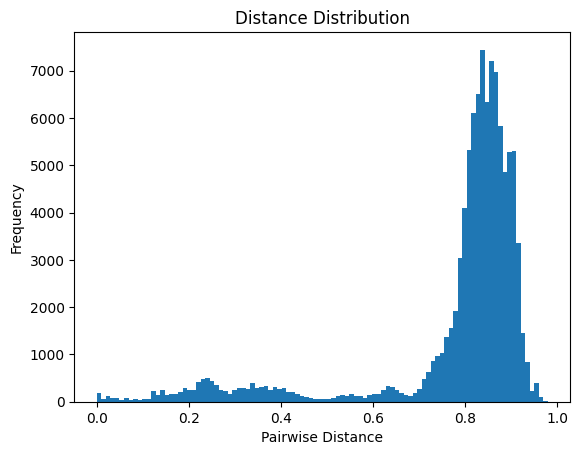

In [9]:
df = matriz_distancias
ssn.df = df

# plot de distancias
plot = ssn.plot_distance_histogram()

Plotting the distance distribution can be helpful to decide good threshold distance values. We can see that beyond 0.6, distances count start to drop to finally explode in higher ranges. These can be an indication that meaningfull interactions appear below this point, that sequences aggregate best at these ranges.

We could use this value as threshold, but it is much more interesting to consider flexible distance thresholds based on individual protein relationships. We will consider two gate values that acts as general thresholds: below the get_all distance, all interactions will be automatically considered valid for clustering; and above omit_all threshold, no interaction will be considered as so, regardless of neighbour count. 0.1 and 0.6 will be the gate thresholds (same as paper, see methodology).

Other parameters will be used to address individual protein networks. These parameters are meant to capture protein-bases relation semantcs rather that global hard-tuned thresholds. These parameters decide protein-based relation thresholds to include within the same clusters sequences that are found within these get_all and omit_all gates, based on neighbours found at these distances. For the sake of clarity, these hyperparameters will be the same as the ones used in the paper.

#### 3. Calculate clusters and building the Network

In [10]:
# Analyze all sequences with default hyperparameters
results = ssn.all_results = {seq: ssn.analyze_seq(seq) for seq in df.index}

# Build NetworkX graph
ssn.buildNetwork(out_folder="ssn_heuristic_test_08ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn = ssn.getGraph()
score = SSNBuilder.score_ssn(G_ssn)

score


Net file written: ssn_heuristic_test_08ABR26/net_single.net
Edges: 1427, Nodes: 455


-9.832312925170068

#### Hyperparameter Tuning

You can do a small hyperparameter optimization for calcuating r_ parameters to ensure quality SSN (see score function in code)

In [11]:
r1_vals = np.linspace(5e-4, 2e-3, 5)
r2_vals = np.linspace(1e-3, 6e-3, 5)
r3_vals = np.linspace(1e-2, 5e-2, 5)

best_score = -np.inf
best_params = None

for r1 in r1_vals:
    for r2 in r2_vals:
        for r3 in r3_vals:
            if not (r1 < r2 < r3):
                continue

            # Reset previous results
            ssn.all_results = {}

            # Run per-sequence histogram analysis
            for seq in ssn.df.index:
                ssn.analyze_seq(seq, r1=r1, r2=r2, r3=r3)

            # Build the graph from all results
            G = ssn.getGraph()

            # Score the graph
            s = SSNBuilder.score_ssn(G)

            if s > best_score:
                best_score = s
                best_params = (r1, r2, r3)

print("Optimal r1,r2,r3:", best_params, "Score:", best_score)

Optimal r1,r2,r3: (0.0005, 0.001, 0.01) Score: -9.832312925170068


In [20]:
# Analyze all sequences with optimized hyperparameters
results = ssn.all_results = {seq: ssn.analyze_seq(seq , r1=0.0005, r2=0.001, r3=0.01) for seq in df.index}

# Build NetworkX graph
ssn.buildNetwork(out_folder="ssn_heuristic_test_08ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn = ssn.getGraph()
score = SSNBuilder.score_ssn(G_ssn)

score

Net file written: ssn_heuristic_test_08ABR26/net_single.net
Edges: 1427, Nodes: 455


-9.832312925170068

#### Score Function

The score_ssn function evaluates a Sequence Similarity Network (SSN) based on its topology. It gives a higher score to networks that are “well-structured” according to three criteria: average degree, largest connected component, and number of components.

Variables
N → Number of nodes in the network (sequences).

E → Number of edges (connections between sequences).

k = 2*E/N → Average node degree. Each edge connects two nodes.

lcc_frac → Fraction of nodes in the Largest Connected Component (LCC).

Con mis datos: 
E = 2423
N = 620

k = 2*E/N -> 7.8

## PETases Combo - pipeline Chema

Vamos a repetir el pipeline anterior pero ahora con la adición de 220 PETases de referencia para ver si los clústers que se han formado están presentes. 
Se ha calculado el PIM y la MD en conjunto.

In [14]:
# usaremos el archivo FASTA y definimos una carpeta destino
archivo_fasta_combo = "C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/PETases_combo_FASTA_08ABR26.txt"
output_folder_combo = "archivos_clustalomega"

In [15]:
ssn_combo = SSNBuilder(archivo_fasta_combo, output_folder_combo)

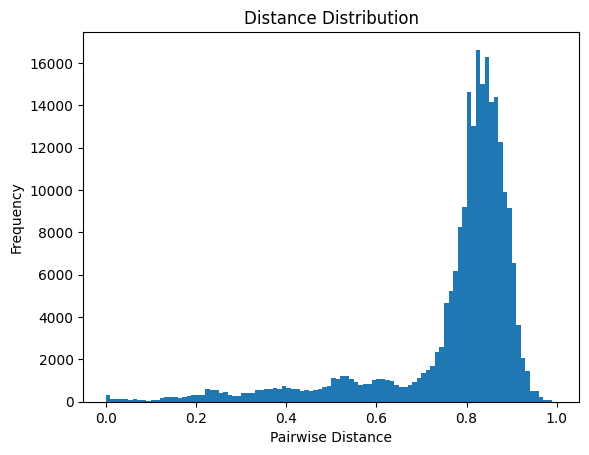

In [16]:
df_combo = matriz_distancias_combo
ssn_combo.df = df_combo

# plot de distancias
plot_combo = ssn_combo.plot_distance_histogram()

In [17]:
# Analyze all sequences with default hyperparameters
results_combo = ssn_combo.all_results = {seq: ssn_combo.analyze_seq(seq) for seq in df_combo.index}

# Build NetworkX graph
ssn_combo.buildNetwork(out_folder="ssn_heuristic_test_combo_08ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn_combo = ssn_combo.getGraph()
score_combo = SSNBuilder.score_ssn(G_ssn_combo)

score_combo

Net file written: ssn_heuristic_test_combo_08ABR26/net_single.net
Edges: 2131, Nodes: 681


-12.241472868217055

In [18]:
r1_vals = np.linspace(5e-4, 2e-3, 5)
r2_vals = np.linspace(1e-3, 6e-3, 5)
r3_vals = np.linspace(1e-2, 5e-2, 5)

best_score = -np.inf
best_params = None

for r1 in r1_vals:
    for r2 in r2_vals:
        for r3 in r3_vals:
            if not (r1 < r2 < r3):
                continue

            # Reset previous results
            ssn_combo.all_results = {}

            # Run per-sequence histogram analysis
            for seq in ssn_combo.df.index:
                ssn_combo.analyze_seq(seq, r1=r1, r2=r2, r3=r3)

            # Build the graph from all results
            G_combo = ssn_combo.getGraph()

            # Score the graph
            s = SSNBuilder.score_ssn(G_combo)

            if s > best_score:
                best_score = s
                best_params = (r1, r2, r3)

print("Optimal r1,r2,r3:", best_params, "Score:", best_score)

Optimal r1,r2,r3: (0.0016250000000000001, 0.0022500000000000003, 0.01) Score: -5.467791411042945


In [19]:
# Analyze all sequences with optimized hyperparameters
results_combo = ssn_combo.all_results = {seq: ssn_combo.analyze_seq(seq , r1=0.0016250000000000001, r2=0.0022500000000000003, r3=0.01) for seq in df_combo.index}

# Build NetworkX graph
ssn_combo.buildNetwork(out_folder="ssn_heuristic_test_combo_08ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn_combo = ssn_combo.getGraph()
score_combo = SSNBuilder.score_ssn(G_ssn_combo)

score_combo

Net file written: ssn_heuristic_test_combo_08ABR26/net_single.net
Edges: 3186, Nodes: 681


-5.467791411042945

## PETasas Totales - pipeline Chema

A 27 de abril de 2026, repetimos la ssn para todas las PETasas: extremas, no extremas o moderadas con el objetivo de colorearlas por estos factores para ver como se organizan.

In [9]:
# usaremos el archivo FASTA y definimos una carpeta destino
archivo_fasta_combo = "C:/Users/HP/OneDrive/Escritorio/Practicas_pLMs/snn_27ABR26_PETasas_totales/PETases_totales_FASTA.fa"
output_folder_combo = "Practicas_pLMs"

In [11]:
ssn_total = SSNBuilder(archivo_fasta_combo, output_folder_combo)

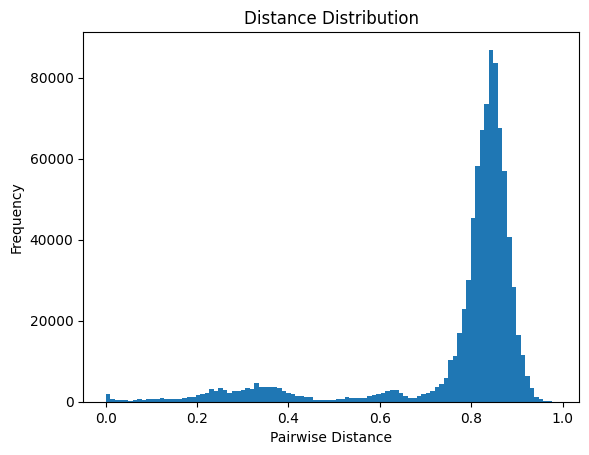

In [12]:
df_total = matriz_distancias_totales
ssn_total.df = df_total

# plot de distancias
plot_total = ssn_total.plot_distance_histogram()

In [13]:
# Analyze all sequences with default hyperparameters
results_total= ssn_total.all_results = {seq: ssn_total.analyze_seq(seq) for seq in df_total.index}

# Build NetworkX graph
ssn_total.buildNetwork(out_folder="ssn_heuristic_test_total_27ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn_total = ssn_total.getGraph()
score_total = SSNBuilder.score_ssn(G_ssn_total)

score_total

Net file written: ssn_heuristic_test_total_27ABR26/net_single.net
Edges: 10610, Nodes: 1322


-13.746535796766743

In [14]:
r1_vals = np.linspace(5e-4, 2e-3, 5)
r2_vals = np.linspace(1e-3, 6e-3, 5)
r3_vals = np.linspace(1e-2, 5e-2, 5)

best_score = -np.inf
best_params = None

for r1 in r1_vals:
    for r2 in r2_vals:
        for r3 in r3_vals:
            if not (r1 < r2 < r3):
                continue

            # Reset previous results
            ssn_total.all_results = {}

            # Run per-sequence histogram analysis
            for seq in ssn_total.df.index:
                ssn_total.analyze_seq(seq, r1=r1, r2=r2, r3=r3)

            # Build the graph from all results
            G_total = ssn_total.getGraph()

            # Score the graph
            s = SSNBuilder.score_ssn(G_total)

            if s > best_score:
                best_score = s
                best_params = (r1, r2, r3)

print("Optimal r1,r2,r3:", best_params, "Score:", best_score)

Optimal r1,r2,r3: (0.000875, 0.001, 0.01) Score: -13.746535796766743


In [15]:
# Analyze all sequences with optimized hyperparameters
results_total = ssn_total.all_results = {seq: ssn_total.analyze_seq(seq , r1=0.000875, r2=0.001, r3=0.01) for seq in df_total.index}

# Build NetworkX graph
ssn_total.buildNetwork(out_folder="ssn_heuristic_test_total_27ABR26/")

# Score Network (useful for hyperparameter optimization)
G_ssn_total = ssn_total.getGraph()
score_total = SSNBuilder.score_ssn(G_ssn_total)

score_total

Net file written: ssn_heuristic_test_total_27ABR26/net_single.net
Edges: 10610, Nodes: 1322


-13.746535796766743